<a href="https://colab.research.google.com/github/gmcls/android-play-location/blob/master/C%C3%B3pia_de_Sierpinski_conectado_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Triângulo de Sierpiński eletricamente conectado

Este notebook desenha um triângulo de Sierpiński de ordem **n** com pontes de largura finita nos pontos de encontro. Isso evita contatos puramente matemáticos, de área zero, que não são confiáveis para impressão e metalização.

1. Altere os parâmetros na célula seguinte.
2. Execute **Ambiente de execução → Executar tudo**.
3. O notebook mostra a figura e gera arquivos **SVG** e **PNG**, reunidos em um ZIP.

> O SVG é vetorial e conserva as dimensões físicas definidas em milímetros. As pontes modificam a geometria eletromagnética e devem fazer parte do modelo no HFSS/CST.

In [ ]:
# ============================================================
# PARÂMETROS — altere estes valores
# ============================================================
ORDEM = 5                 # Ordem n: use normalmente valores de 0 a 7
LADO_MM = 100.0           # Lado externo do triângulo, em milímetros
LARGURA_PONTE_MM = 1.0    # Diâmetro mínimo das conexões condutoras
DPI_PNG = 600             # Resolução da imagem PNG
COR_METAL = 'black'       # Região que será metalizada
BAIXAR_ZIP_AUTOMATICAMENTE = True

# Verificações básicas
if not isinstance(ORDEM, int) or ORDEM < 0:
    raise ValueError('ORDEM deve ser um número inteiro maior ou igual a zero.')
if ORDEM > 9:
    raise ValueError('Use ORDEM até 9 para evitar um arquivo excessivamente grande.')
if LADO_MM <= 0:
    raise ValueError('LADO_MM deve ser maior que zero.')
if LARGURA_PONTE_MM <= 0:
    raise ValueError('LARGURA_PONTE_MM deve ser maior que zero.')


In [ ]:
import math
import os
import zipfile
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle
from matplotlib.path import Path

def ponto_medio(p, q):
    return ((p[0] + q[0]) / 2.0, (p[1] + q[1]) / 2.0)

def construir_sierpinski(a, b, c, ordem, triangulos, contatos):
    '''Gera triângulos sólidos e pontos que receberão as pontes.'''
    if ordem == 0:
        triangulos.append((a, b, c))
        return

    ab = ponto_medio(a, b)
    ac = ponto_medio(a, c)
    bc = ponto_medio(b, c)

    # Três cópias de ordem n-1.
    construir_sierpinski(a, ab, ac, ordem - 1, triangulos, contatos)
    construir_sierpinski(ab, b, bc, ordem - 1, triangulos, contatos)
    construir_sierpinski(ac, bc, c, ordem - 1, triangulos, contatos)

    # Os discos centrados nestes pontos criam contatos de área finita.
    contatos.extend((ab, ac, bc))

def gerar_arquivos(ordem, lado_mm, largura_ponte_mm, dpi=600, cor='black'):
    altura_mm = lado_mm * math.sqrt(3.0) / 2.0

    # Vértices do triângulo externo.
    a = (lado_mm / 2.0, altura_mm)
    b = (0.0, 0.0)
    c = (lado_mm, 0.0)

    triangulos = []
    contatos = []
    construir_sierpinski(a, b, c, ordem, triangulos, contatos)

    # O tamanho da figura é definido em polegadas para que o SVG preserve mm.
    fig = plt.figure(figsize=(lado_mm / 25.4, altura_mm / 25.4), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, lado_mm)
    ax.set_ylim(0, altura_mm)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Recorte global: nenhuma ponte ultrapassa o contorno externo.
    contorno = Path([a, b, c, a])

    for vertices in triangulos:
        regiao = Polygon(vertices, closed=True, facecolor=cor, edgecolor='none')
        regiao.set_clip_path(contorno, ax.transData)
        ax.add_patch(regiao)

    raio = largura_ponte_mm / 2.0
    for x, y in contatos:
        ponte = Circle((x, y), raio, facecolor=cor, edgecolor='none')
        ponte.set_clip_path(contorno, ax.transData)
        ax.add_patch(ponte)

    base = f'sierpinski_n{ordem}_{lado_mm:g}mm_ponte{largura_ponte_mm:g}mm'
    arquivo_svg = base + '.svg'
    arquivo_png = base + '.png'
    arquivo_zip = base + '.zip'

    # Não usar bbox_inches='tight': isso alteraria a escala física do SVG.
    fig.savefig(arquivo_svg, format='svg', facecolor='white')
    fig.savefig(arquivo_png, format='png', dpi=dpi, facecolor='white')
    plt.show()
    plt.close(fig)

    with zipfile.ZipFile(arquivo_zip, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(arquivo_svg)
        zf.write(arquivo_png)

    lado_menor = lado_mm / (2 ** ordem)
    print(f'Ordem: {ordem}')
    print(f'Lado externo: {lado_mm:g} mm')
    print(f'Lado dos menores triângulos: {lado_menor:g} mm')
    print(f'Largura das pontes: {largura_ponte_mm:g} mm')
    print(f'Triângulos sólidos: {len(triangulos)}')
    print(f'Arquivos gerados: {arquivo_svg}, {arquivo_png} e {arquivo_zip}')

    if largura_ponte_mm > 0.4 * lado_menor:
        print('ATENÇÃO: a ponte é relativamente larga para o menor triângulo e altera bastante o fractal.')

    return arquivo_svg, arquivo_png, arquivo_zip


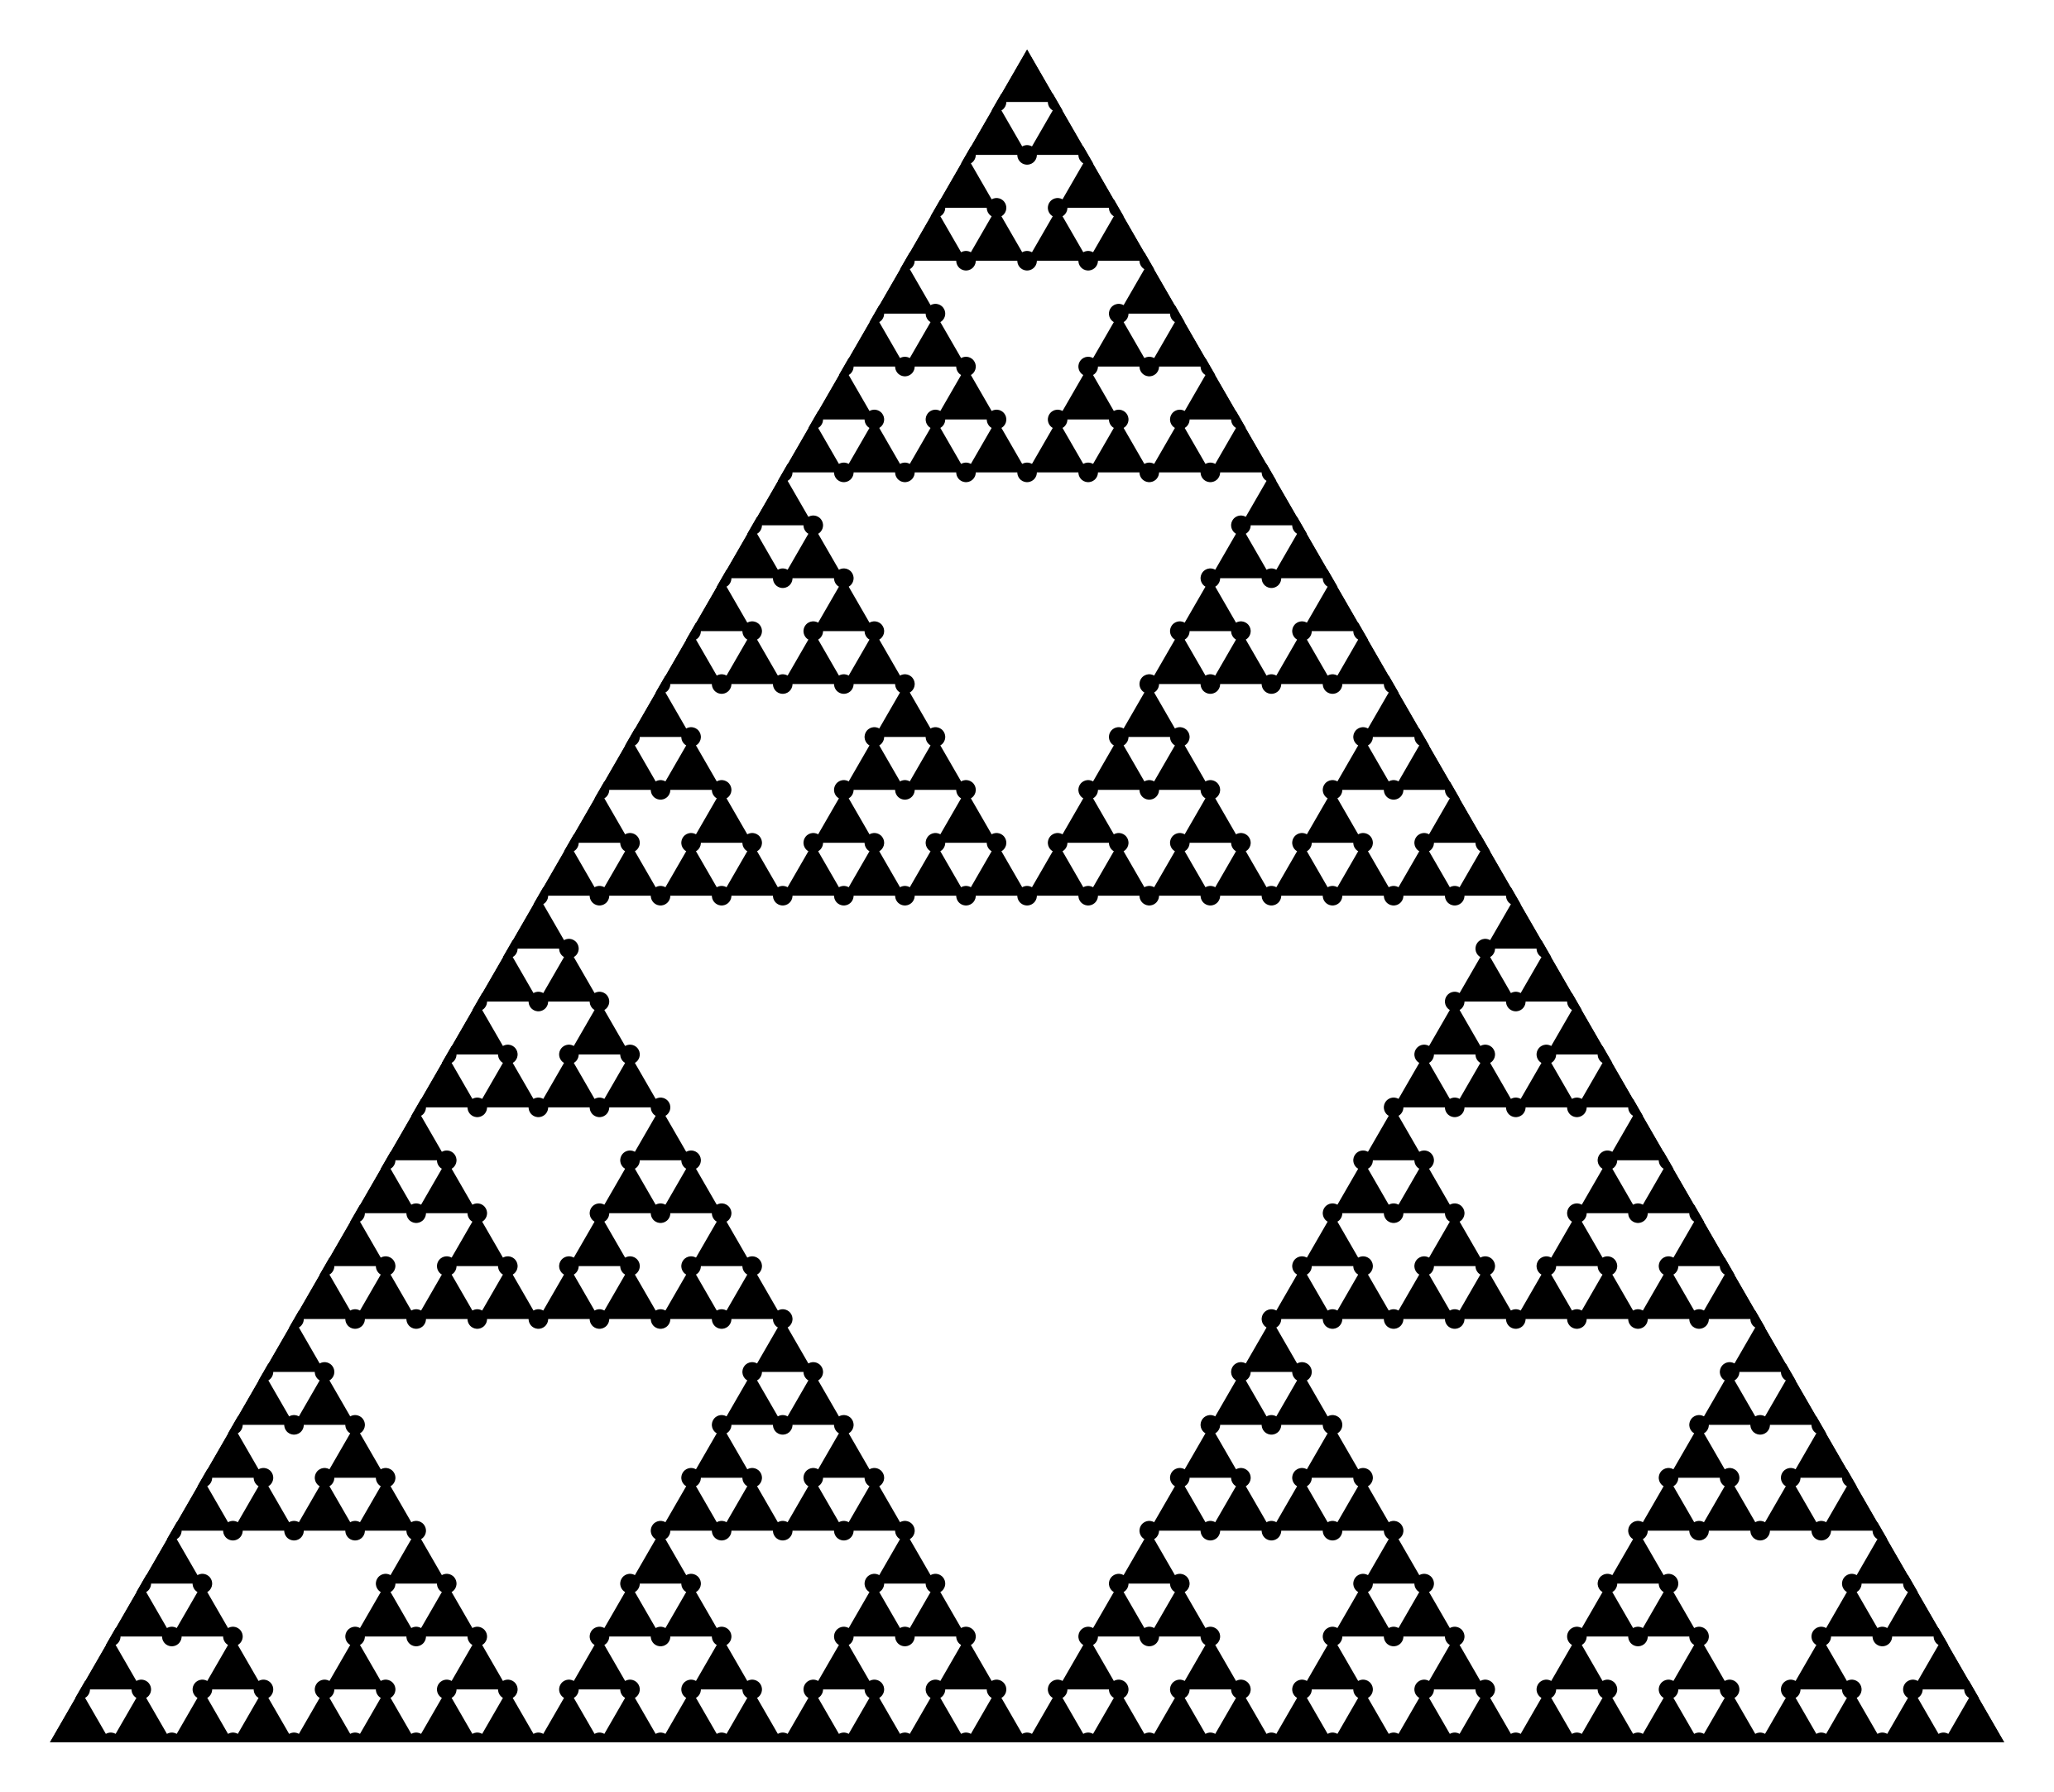

Ordem: 5
Lado externo: 100 mm
Lado dos menores triângulos: 3.125 mm
Largura das pontes: 1 mm
Triângulos sólidos: 243
Arquivos gerados: sierpinski_n5_100mm_ponte1mm.svg, sierpinski_n5_100mm_ponte1mm.png e sierpinski_n5_100mm_ponte1mm.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
arquivo_svg, arquivo_png, arquivo_zip = gerar_arquivos(
    ORDEM,
    LADO_MM,
    LARGURA_PONTE_MM,
    dpi=DPI_PNG,
    cor=COR_METAL,
)

if BAIXAR_ZIP_AUTOMATICAMENTE:
    try:
        from google.colab import files
        files.download(arquivo_zip)
    except ImportError:
        print('Fora do Google Colab: o ZIP ficou salvo na pasta atual.')


## Observações para fabricação

- A largura informada é o **diâmetro dos discos de conexão**.
- Escolha uma largura compatível com a resolução da impressão e a continuidade da metalização.
- Para uso como antena, importe o SVG ou reconstrua a geometria no simulador e inclua as pontes na simulação.
- Confirme a escala do SVG no programa de fabricação: o lado externo deve medir exatamente `LADO_MM`.